# ESMFold + PropKa vs ProtParam pI validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from scipy import stats
from pathlib import Path

MM = 1 / 25.4
COL1 = 88  * MM   
COL2 = 180 * MM  
FH   = 60  * MM  

FONT_FAMILY = 'Arial'
LABEL_SIZE  = 7
TICK_SIZE   = 6
TITLE_SIZE  = 7

C_MAIN   = '#3CAB92'   
C_GREY   = '#888888'  
C_RED    = '#D6604D'  
C_FILL   = '#DEEBF7'  

matplotlib.rcParams.update({
    'font.family'       : FONT_FAMILY,
    'font.size'         : LABEL_SIZE,
    'axes.labelsize'    : LABEL_SIZE,
    'axes.titlesize'    : TITLE_SIZE,
    'xtick.labelsize'   : TICK_SIZE,
    'ytick.labelsize'   : TICK_SIZE,
    'axes.linewidth'    : 0.6,
    'xtick.major.width' : 0.6,
    'ytick.major.width' : 0.6,
    'xtick.major.size'  : 2.5,
    'ytick.major.size'  : 2.5,
    'lines.linewidth'   : 0.8,
    'legend.fontsize'   : 6,
    'legend.frameon'    : False,
    'pdf.fonttype'      : 42,   
    'svg.fonttype'      : 'none',
})

OUT_DIR = Path('figures_propka_validation')
OUT_DIR.mkdir(exist_ok=True)

def save(fig, name):
    for ext in ['svg', 'png']:
        fig.savefig(OUT_DIR / f'{name}.{ext}', dpi=300,
                    bbox_inches='tight', facecolor='white')
    print(f'Saved {name}')

In [2]:
# Load data
df_all = pd.read_csv('/Users/skoog/Desktop/esmfold_propka_pi_comparison.tsv', sep='\t')
print(f'Total rows: {len(df_all)}')
print(df_all['status'].value_counts())
df = df_all[df_all['status'] == 'ok'].copy()
df = df.dropna(subset=['protparam_pI', 'propka_pI'])
print(f'\nUsable for comparison: {len(df)}')
df.head()

Total rows: 71
status
ok          49
too_long    18
api_fail     4
Name: count, dtype: int64

Usable for comparison: 49


,protein_id,seq_len,protparam_pI,propka_pI,delta,status
0,WATLvirus_00012614_6,242,5.95,6.95,1.00,ok
1,WATLvirus_00020186_2,398,5.22,5.69,0.47,ok
2,WATLvirus_00023771_19,337,5.15,5.43,0.28,ok
3,WATLvirus_00035274_1,291,4.05,4.08,0.03,ok
4,WATLvirus_00045143_4,386,4.86,5.04,0.18,ok


In [3]:
# Summary stats 
deltas   = df['delta'].values
abs_d    = np.abs(deltas)
r, p     = stats.pearsonr(df['protparam_pI'], df['propka_pI'])
rho, p2  = stats.spearmanr(df['protparam_pI'], df['propka_pI'])
mean_d   = np.mean(deltas)
sd_d     = np.std(deltas, ddof=1)
med_d    = np.median(deltas)
med_abs  = np.median(abs_d)

print(f'n = {len(df)}')
print(f'Pearson r = {r:.3f}  (p = {p:.2e})')
print(f'Spearman ρ = {rho:.3f}  (p = {p2:.2e})')
print(f'Mean delta (PropKa − ProtParam) = {mean_d:+.3f}')
print(f'Median delta                    = {med_d:+.3f}')
print(f'SD of delta                     = {sd_d:.3f}')
print(f'Median |delta|                  = {med_abs:.3f}')
print(f'95% LoA: [{mean_d - 1.96*sd_d:.3f}, {mean_d + 1.96*sd_d:.3f}]')

n = 49
Pearson r = 0.985  (p = 2.76e-37)
Spearman ρ = 0.981  (p = 6.01e-35)
Mean delta (PropKa − ProtParam) = +0.360
Median delta                    = +0.260
SD of delta                     = 0.364
Median |delta|                  = 0.260
95% LoA: [-0.353, 1.073]


Saved FigS_scatter_pI_seq_vs_struct


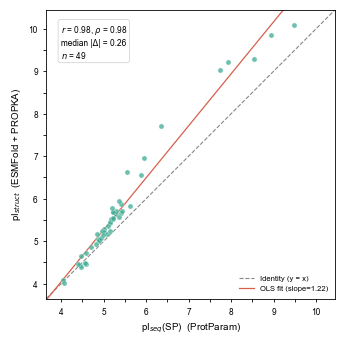

In [4]:
#fig1
lo   = min(df['protparam_pI'].min(), df['propka_pI'].min())
hi   = max(df['protparam_pI'].max(), df['propka_pI'].max())
pad  = 0.06 * (hi - lo)
lims = [lo - pad, hi + pad]

fig, ax = plt.subplots(figsize=(COL1, COL1))

ax.scatter(df['protparam_pI'], df['propka_pI'],
           s=14, color=C_MAIN, alpha=0.75,
           linewidths=0.3, edgecolors='white', zorder=3)

# y = x identity line
ax.plot(lims, lims, '--', color=C_GREY, lw=0.8, zorder=2, label='Identity (y = x)')

# OLS regression line
slope, intercept, *_ = stats.linregress(df['protparam_pI'], df['propka_pI'])
x_fit = np.linspace(*lims, 100)
ax.plot(x_fit, slope * x_fit + intercept,
        color=C_RED, lw=0.9, zorder=2,
        label=f'OLS fit (slope={slope:.2f})')


ann = (f'$r$ = {r:.2f}, $\\rho$ = {rho:.2f}\n'
       f'median |Δ| = {med_abs:.2f}\n'
       f'$n$ = {len(df)}')
ax.text(0.05, 0.95, ann, transform=ax.transAxes,
        va='top', ha='left', fontsize=6,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', lw=0.5))

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('pI$_{seq}$(SP)  (ProtParam)')
ax.set_ylabel('pI$_{struct}$  (ESMFold + PROPKA)')
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.legend(loc='lower right', fontsize=5.5)
ax.set_aspect('equal', adjustable='box')
for c in ax.collections:          # re-clip after aspect resizes the box
    c.set_clip_path(ax.patch)

fig.tight_layout()
save(fig, 'FigS_scatter_pI_seq_vs_struct')
plt.show()


Saved FigS_bland_altman


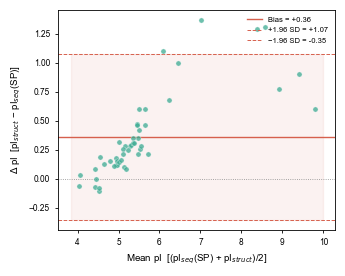

In [5]:
#fig2
mean_vals = (df['protparam_pI'] + df['propka_pI']) / 2
loa_lo = mean_d - 1.96 * sd_d
loa_hi = mean_d + 1.96 * sd_d

fig, ax = plt.subplots(figsize=(COL1, COL1 * 0.8))

ax.scatter(mean_vals, deltas,
           s=14, color=C_MAIN, alpha=0.75,
           linewidths=0.3, edgecolors='white', zorder=3)

ax.axhline(mean_d,  color=C_RED,  lw=1.0, ls='-',  label=f'Bias = {mean_d:+.2f}')
ax.axhline(loa_hi,  color=C_RED,  lw=0.7, ls='--', label=f'+1.96 SD = {loa_hi:+.2f}')
ax.axhline(loa_lo,  color=C_RED,  lw=0.7, ls='--', label=f'−1.96 SD = {loa_lo:+.2f}')
ax.axhline(0,       color=C_GREY, lw=0.6, ls=':')

# Shade LoA band
ax.fill_between([mean_vals.min()-0.2, mean_vals.max()+0.2],
                loa_lo, loa_hi, alpha=0.08, color=C_RED)

ax.set_xlabel('Mean pI  [(pI$_{seq}$(SP) + pI$_{struct}$)/2]')
ax.set_ylabel('Δ pI  [pI$_{struct}$ − pI$_{seq}$(SP)]')
ax.legend(loc='upper right', fontsize=5.5)
ax.yaxis.set_minor_locator(MultipleLocator(0.25))

fig.tight_layout()
save(fig, 'FigS_bland_altman')
plt.show()

Saved FigS_delta_histogram


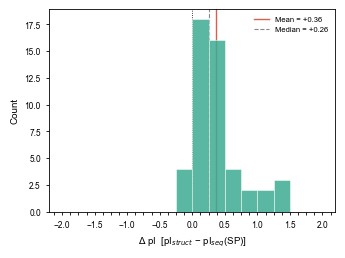

In [6]:
fig, ax = plt.subplots(figsize=(COL1, COL1 * 0.75))

bins = np.arange(-2.0, 2.25, 0.25)
ax.hist(deltas, bins=bins, color=C_MAIN, alpha=0.85,
        edgecolor='white', linewidth=0.4, zorder=3)

ax.axvline(mean_d,  color=C_RED,  lw=1.0, ls='-',  label=f'Mean = {mean_d:+.2f}')
ax.axvline(med_d,   color=C_GREY, lw=0.8, ls='--', label=f'Median = {med_d:+.2f}')
ax.axvline(0,       color='black', lw=0.6, ls=':')

ax.set_xlabel('Δ pI  [pI$_{struct}$ − pI$_{seq}$(SP)]')
ax.set_ylabel('Count')
ax.legend(fontsize=5.5)
ax.xaxis.set_minor_locator(MultipleLocator(0.125))

fig.tight_layout()
save(fig, 'FigS_delta_histogram')
plt.show()

Saved FigS_propka_validation_composite


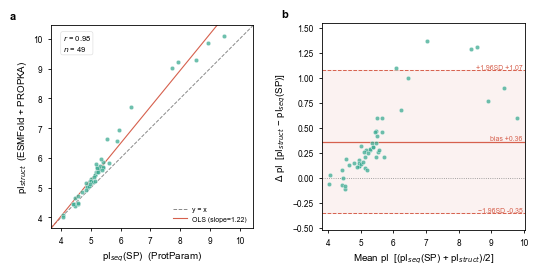

All figures saved to figures_propka_validation


In [7]:

lo   = min(df['protparam_pI'].min(), df['propka_pI'].min())
hi   = max(df['protparam_pI'].max(), df['propka_pI'].max())
pad  = 0.06 * (hi - lo)
lims = [lo - pad, hi + pad]
slope, intercept, *_ = stats.linregress(df['protparam_pI'], df['propka_pI'])
x_fit = np.linspace(*lims, 100)

fig = plt.figure(figsize=(140 * MM, 70 * MM))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.34,
                        left=0.09, right=0.95, top=0.92, bottom=0.17)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.scatter(df['protparam_pI'], df['propka_pI'],
            s=10, color=C_MAIN, alpha=0.75,
            linewidths=0.3, edgecolors='white', zorder=3)
ax1.plot(lims, lims, '--', color=C_GREY, lw=0.7, label='y = x')
ax1.plot(x_fit, slope * x_fit + intercept,
         color=C_RED, lw=0.8, label=f'OLS (slope={slope:.2f})')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_aspect('equal', adjustable='box')
for c in ax1.collections:          # re-clip after aspect resizes the box
    c.set_clip_path(ax1.patch)
ax1.set_xlabel('pI$_{seq}$(SP)  (ProtParam)', labelpad=3)
ax1.set_ylabel('pI$_{struct}$  (ESMFold + PROPKA)', labelpad=3)
ax1.legend(fontsize=5, loc='lower right')
ax1.text(0.06, 0.96, f'$r$ = {r:.2f}\n$n$ = {len(df)}',
         transform=ax1.transAxes, va='top', fontsize=5.5,
         bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.85', lw=0.4))
ax1.text(-0.20, 1.03, 'a', transform=ax1.transAxes,
         fontsize=8, fontweight='bold')

# Panel b
xpad = 0.04 * (mean_vals.max() - mean_vals.min())
ax2.scatter(mean_vals, deltas,
            s=10, color=C_MAIN, alpha=0.75,
            linewidths=0.3, edgecolors='white', zorder=3)
ax2.axhline(mean_d, color=C_RED,  lw=0.9)
ax2.axhline(loa_hi, color=C_RED,  lw=0.7, ls='--')
ax2.axhline(loa_lo, color=C_RED,  lw=0.7, ls='--')
ax2.axhline(0,      color=C_GREY, lw=0.6, ls=':')
ax2.set_xlim(mean_vals.min() - xpad, mean_vals.max() + xpad)
ax2.fill_between(ax2.get_xlim(), loa_lo, loa_hi, alpha=0.08, color=C_RED, zorder=0)
ymin = min(deltas.min(), loa_lo); ymax = max(deltas.max(), loa_hi)
ypad = 0.10 * (ymax - ymin)
ax2.set_ylim(ymin - ypad, ymax + ypad)
for yv, lab in [(mean_d, f'bias {mean_d:+.2f}'),
                (loa_hi, f'+1.96SD {loa_hi:+.2f}'),
                (loa_lo, f'−1.96SD {loa_lo:+.2f}')]:
    ax2.annotate(lab, xy=(0.99, yv), xycoords=('axes fraction', 'data'),
                 ha='right', va='bottom', fontsize=5, color=C_RED)
ax2.set_xlabel('Mean pI  [(pI$_{seq}$(SP) + pI$_{struct}$)/2]', labelpad=3)
ax2.set_ylabel('Δ pI  [pI$_{struct}$ − pI$_{seq}$(SP)]', labelpad=3)
ax2.yaxis.set_minor_locator(MultipleLocator(0.25))
ax2.text(-0.20, 1.03, 'b', transform=ax2.transAxes,
         fontsize=8, fontweight='bold')

save(fig, 'FigS_propka_validation_composite')
plt.show()
print('All figures saved to', OUT_DIR)


In [8]:
# Is the offset constant?
low  = df[df['protparam_pI'] < 6]
high = df[df['protparam_pI'] > 8]
mid  = df[(df['protparam_pI'] >= 6) & (df['protparam_pI'] <= 8)]

for name, sub in [('pI_seq < 6', low), ('6 <= pI_seq <= 8', mid), ('pI_seq > 8', high)]:
    if len(sub):
        print(f'{name:<18} n={len(sub):>3}  mean Δ={sub["delta"].mean():+.3f}  '
              f'median Δ={sub["delta"].median():+.3f}  max Δ={sub["delta"].max():+.3f}')
    else:
        print(f'{name:<18} n=  0')

rb, pb = stats.pearsonr((df['protparam_pI'] + df['propka_pI']) / 2, df['delta'])



pI_seq < 6         n= 43  mean Δ=+0.265  median Δ=+0.210  max Δ=+1.100
6 <= pI_seq <= 8   n=  3  mean Δ=+1.323  median Δ=+1.310  max Δ=+1.370
pI_seq > 8         n=  3  mean Δ=+0.757  median Δ=+0.770  max Δ=+0.900

Bland-Altman proportional bias: r = 0.782, p = 3.30e-11
